### ML Lab 5
#### Name: Ishika Sahare
#### Section-Batch: B-B2
#### Roll No.: 26

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split,GridSearchCV,cross_val_score,StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score,recall_score,f1_score, confusion_matrix, classification_report,roc_curve,roc_auc_score)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [25]:
df= pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [26]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [27]:
df.shape

(768, 9)

In [28]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [30]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


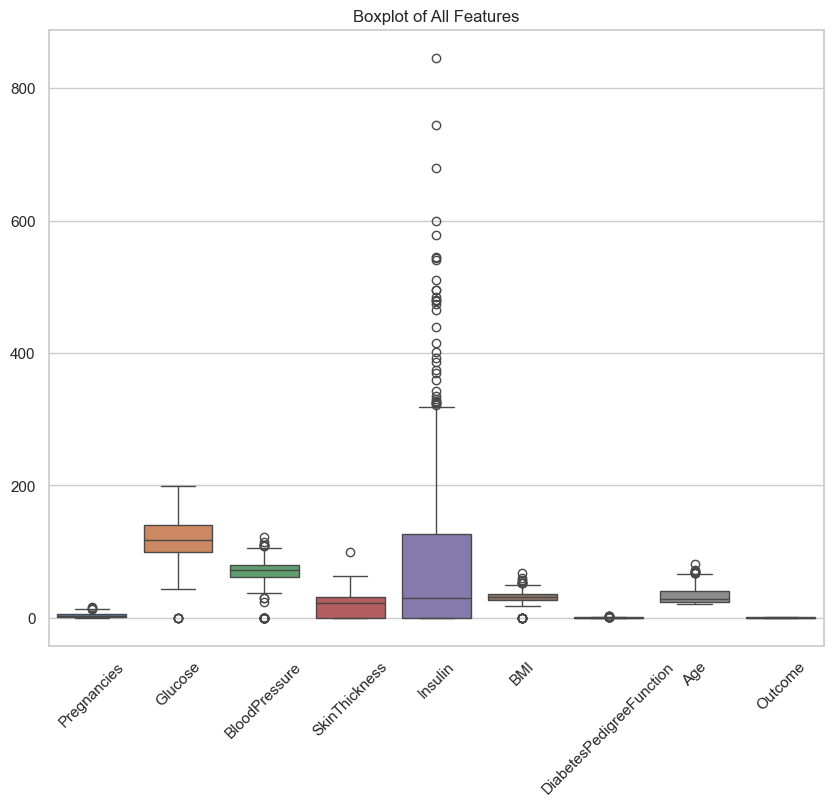

In [31]:
plt.figure(figsize=(10,8))

sns.boxplot(data=df)

plt.title("Boxplot of All Features")
plt.xticks(rotation=45)

plt.show()

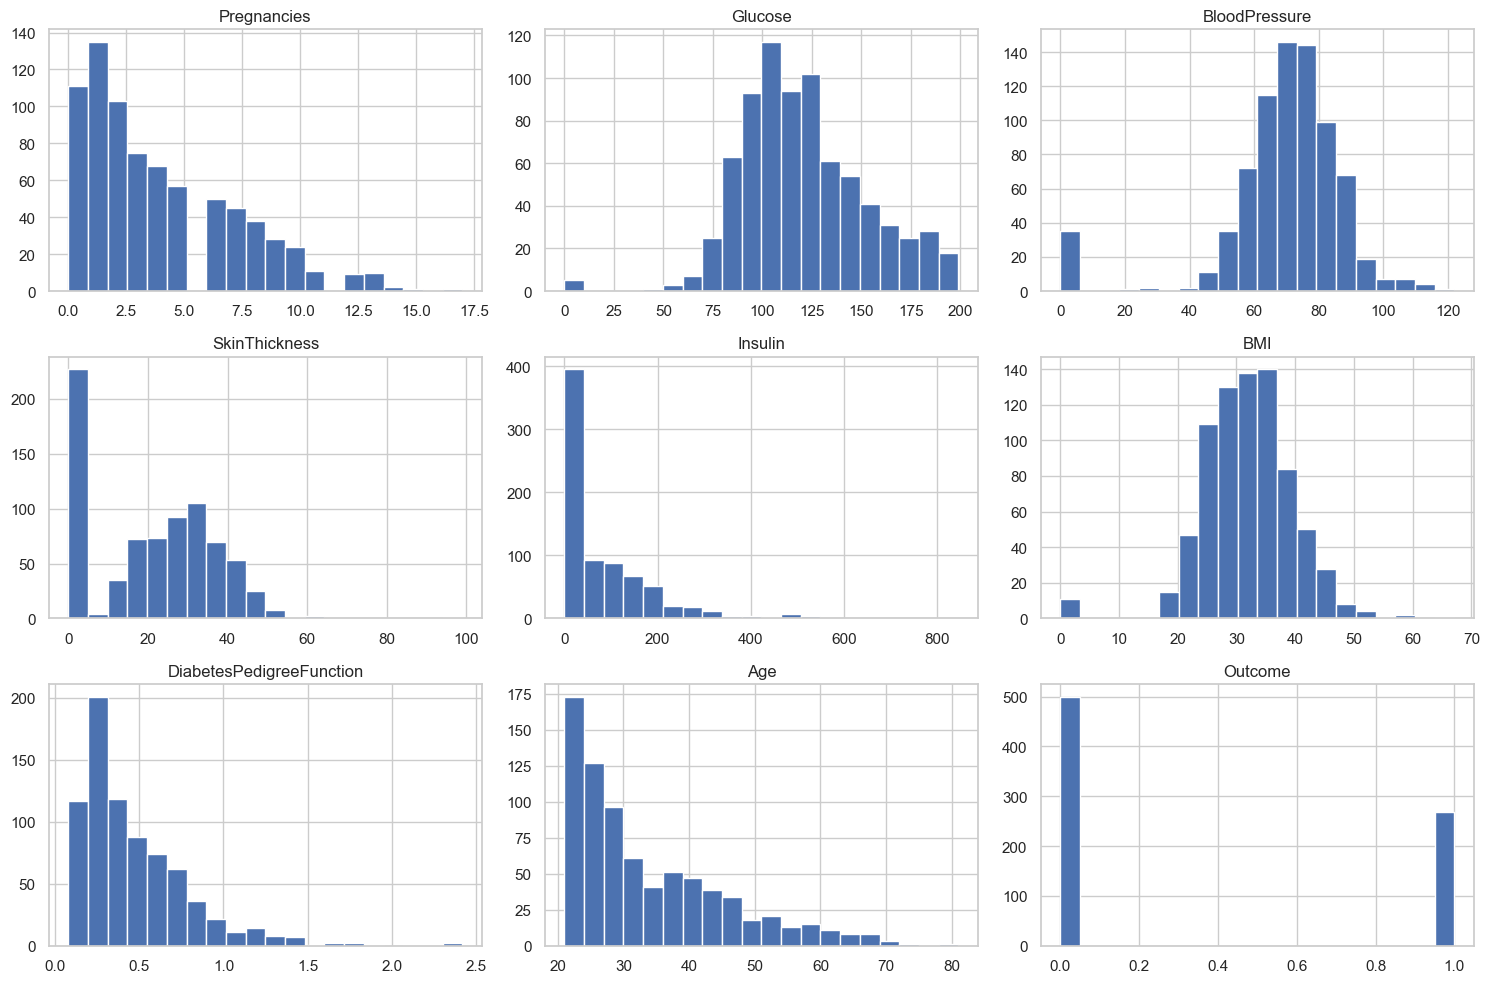

In [32]:
df.hist(figsize=(15,10), bins=20)

plt.tight_layout()
plt.show()

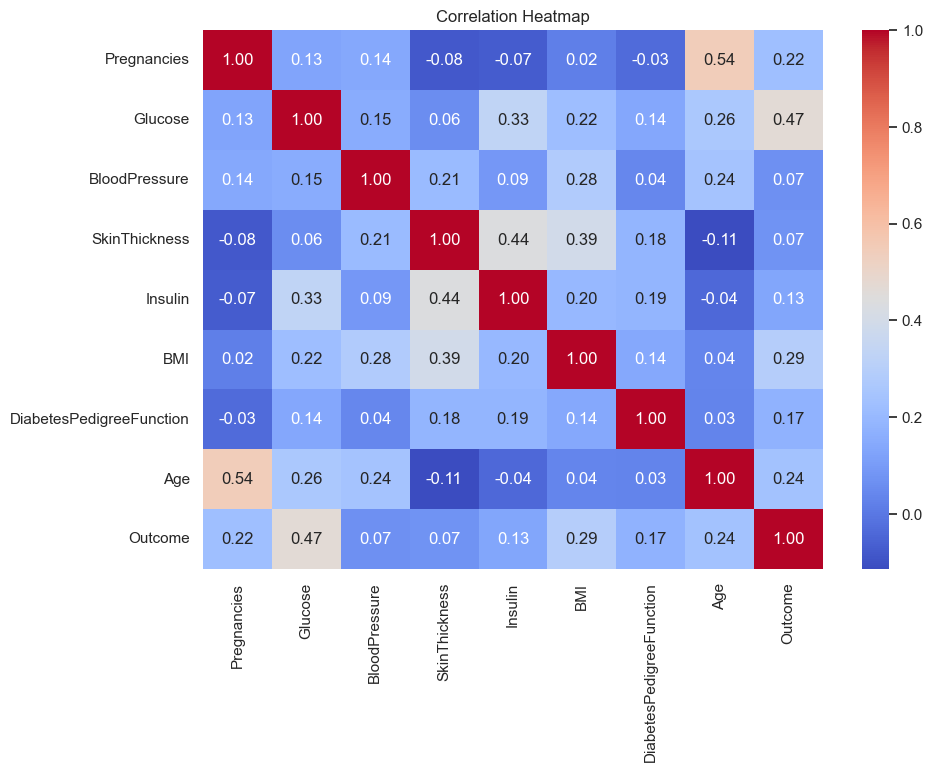

In [33]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [34]:
zero_columns =["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
zero_counts = (df[zero_columns]==0).sum()
print("Zero Values")
print(zero_counts)

Zero Values
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [35]:
df_clean = df.copy()
df_clean[zero_columns]=df_clean[zero_columns].replace(0,np.nan)
print("Missing Values after replacing invalid zeros:")
print(df_clean.isnull().sum())

Missing Values after replacing invalid zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [36]:
for col in zero_columns:
    df_clean[col]=df_clean[col].fillna(df_clean[col].median())
print("Missing Values after median:")
print(df_clean.isnull().sum())

Missing Values after median:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [37]:
X = df_clean.drop("Outcome",axis=1)

y= df_clean["Outcome"]

print("X shape",X.shape)
print(" y Shape ",y.shape)

X shape (768, 8)
 y Shape  (768,)


In [38]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify =y)
print("Training samples:",X_train.shape[0])
print("testing samples:",X_test.shape[0])

Training samples: 614
testing samples: 154


In [39]:
print("Training distribution:")
print(y_train.value_counts(normalize=True))

print("Testing distribution:")
print(y_test.value_counts(normalize=True))

Training distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64
Testing distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [40]:
scaler= StandardScaler()
X_train_scaled = scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

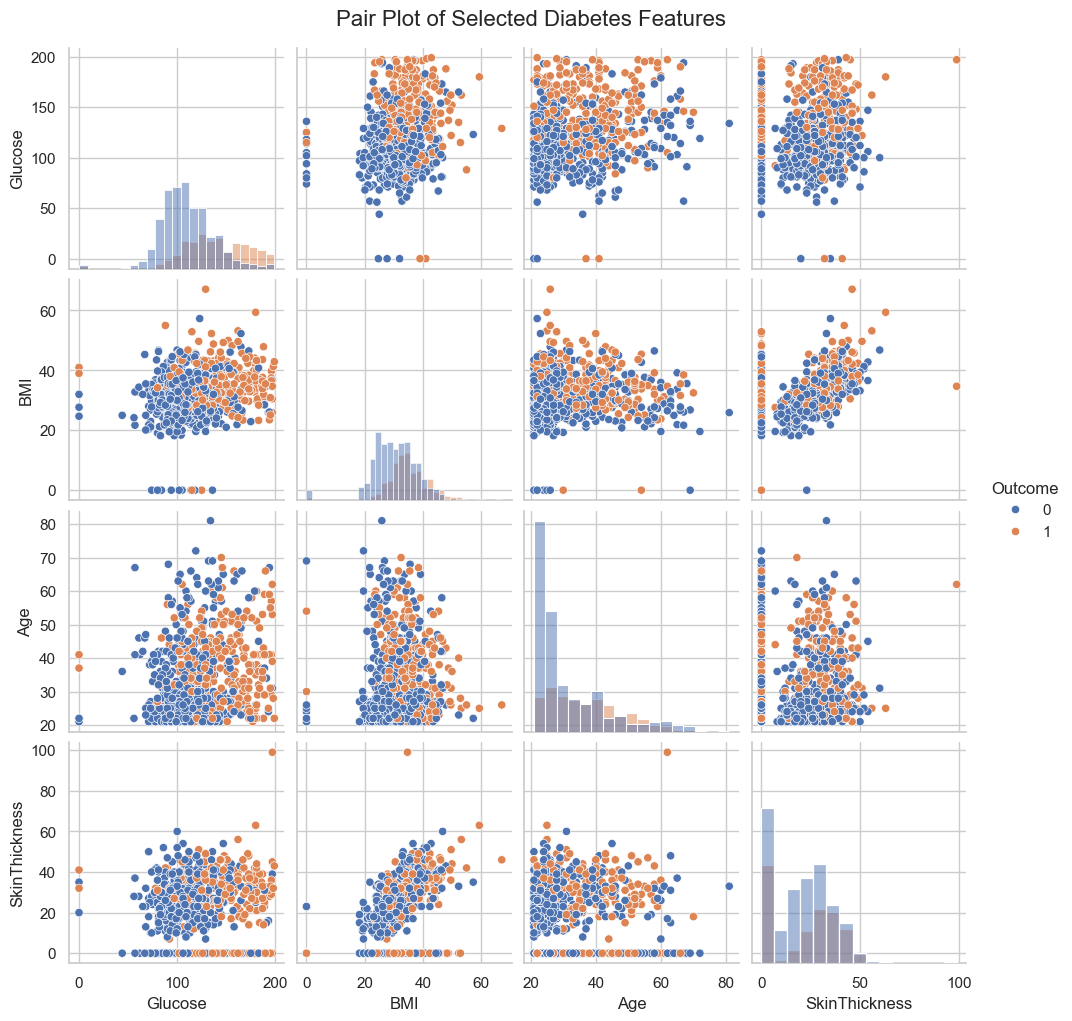

In [64]:
selected_features = [
    "Glucose",
    "BMI",
    "Age",
    "SkinThickness",
    "Outcome"
]

sns.pairplot(
    df[selected_features],
    hue="Outcome",
    diag_kind="hist"
)

plt.suptitle(
    "Pair Plot of Selected Diabetes Features",
    y=1.02,
    fontsize=16
)

plt.show()

In [41]:
k=5

In [42]:
knn =KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [43]:
y_pred = knn.predict(X_test_scaled)
print("Prediction")
print(y_pred)

Prediction
[1 0 0 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0 1 1 0 0
 0 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 1 0 1 0 1 1 1
 1 1 0 0 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 1 0
 0 0 0 0 1 0]


In [44]:
y_prob = knn.predict_proba(X_test_scaled)[:,1]
print(y_prob)

[0.6 0.2 0.2 0.6 0.  0.2 0.2 0.8 0.  0.6 0.4 0.6 0.  0.  0.  0.6 0.8 0.
 1.  0.2 0.4 1.  0.4 0.8 0.2 0.  0.6 0.  0.8 0.  0.  0.  0.4 0.6 0.8 0.2
 0.  0.  0.6 0.4 0.6 0.4 0.  0.2 0.2 0.4 0.  0.  0.6 0.2 0.2 0.8 0.2 0.
 0.6 0.2 0.6 0.  0.8 0.  0.8 0.4 0.2 1.  0.  0.4 1.  0.  0.4 0.8 0.2 0.
 0.2 0.6 0.  0.4 0.  0.8 0.  0.  0.  0.  0.  0.2 0.2 0.  0.4 0.2 0.  0.4
 0.6 0.8 0.2 0.  0.  0.4 0.6 0.6 0.8 0.  0.2 0.  0.  0.2 0.8 0.  0.8 0.
 0.8 0.6 0.6 0.8 0.6 0.2 0.4 0.4 0.2 0.  1.  0.  0.6 0.  0.2 0.6 0.2 0.8
 0.6 0.4 0.  0.2 0.  0.4 0.2 0.8 0.6 0.  0.  0.  0.  0.8 0.  0.6 0.  0.
 0.2 0.  0.6 0.4 0.4 0.  0.2 0.  0.8 0. ]


In [45]:
accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy:{accuracy:.4f}")

Accuracy:0.7532


In [46]:
precision = precision_score(y_test,y_pred)
print(f"Precision:{precision:.4f}")

Precision:0.6600


In [47]:
recall = recall_score(y_test,y_pred)
print(f"Recall: {recall:.4f}")

Recall: 0.6111


In [48]:
f1=f1_score(y_test,y_pred)
print(f"F1 score :{f1:.4f}")

F1 score :0.6346


In [49]:
print(classification_report(y_test, y_pred, target_names=["NoDiabetic", "Diabetic"]))


              precision    recall  f1-score   support

  NoDiabetic       0.80      0.83      0.81       100
    Diabetic       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [50]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[83 17]
 [21 33]]


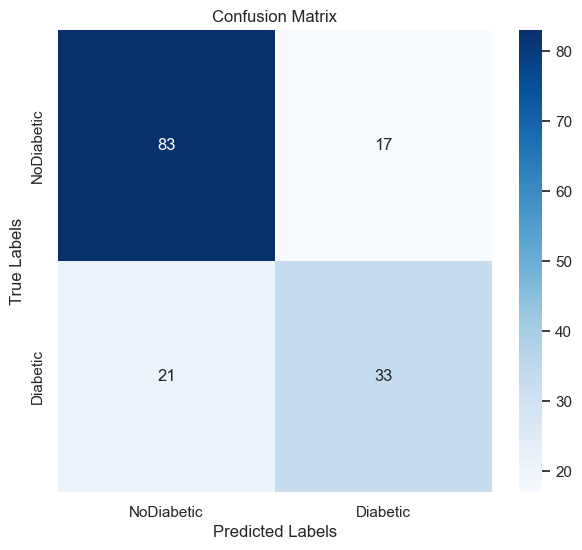

In [51]:
plt.figure(figsize=(7, 6))

class_names = ["NoDiabetic", "Diabetic"]

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.show()

In [52]:
k_values = range(1,31)
train_accuracy = []
test_accuracy = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled,y_train)
    train_accuracy.append(model.score(X_train_scaled,y_train))
    test_accuracy.append(model.score(X_test_scaled,y_test))

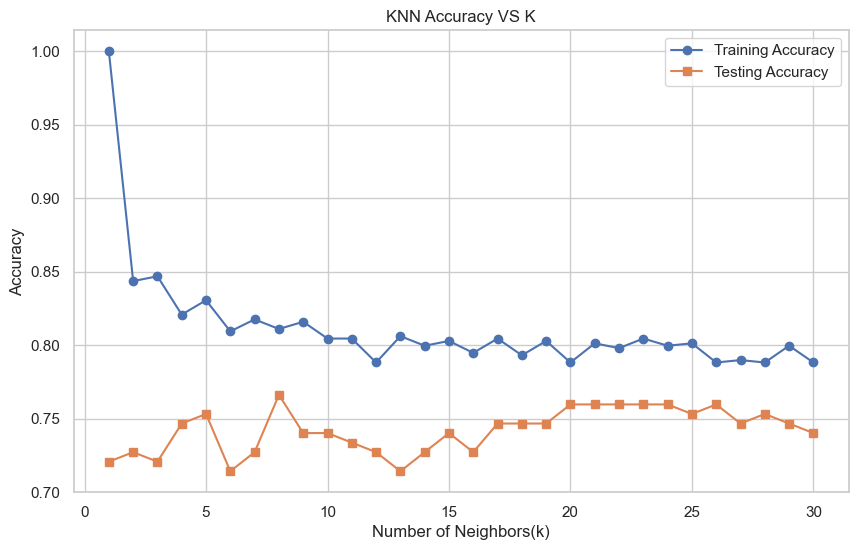

In [53]:
plt.figure(figsize=(10,6))
plt.plot(k_values,train_accuracy,marker="o",label="Training Accuracy")
plt.plot(k_values,test_accuracy,marker="s",label="Testing Accuracy")

plt.xlabel("Number of Neighbors(k)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy VS K")
plt.legend()
plt.grid(True)
plt.show()

In [54]:
best_k_accuracy = k_values[np.argmax(test_accuracy)]
best_accuracy = max(test_accuracy)

print("Best K",best_k_accuracy)
print("Best Test Accuracy:",best_accuracy)

Best K 8
Best Test Accuracy: 0.7662337662337663


In [55]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for k in range(1, 31):
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="accuracy")
    cv_scores.append(scores.mean())


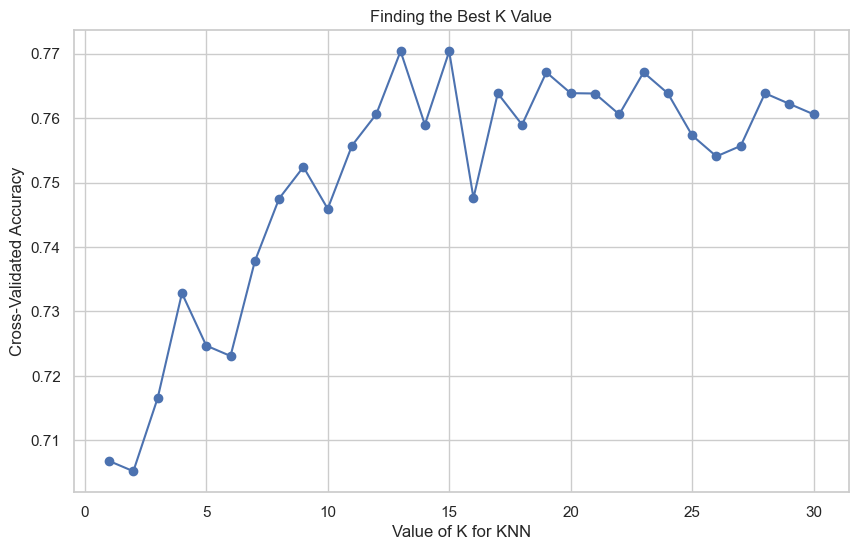

In [56]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 31), cv_scores, marker="o")
plt.xlabel("Value of K for KNN")
plt.ylabel("Cross-Validated Accuracy")
plt.title("Finding the Best K Value")
plt.grid(True)
plt.show()

In [57]:
best_k_cv=np.argmax(cv_scores)+1
print("Best K Based on Cross Validation:",best_k_cv)
print("Best CV Accuracy:",max(cv_scores))

Best K Based on Cross Validation: 13
Best CV Accuracy: 0.7703718512594963


In [58]:
param_grid={"n_neighbors":list(range(3,31,2)),"weights":["uniform","distance"],
           "metric":["eucliden","manhattan","minkowski"],
            "p":[1,2]
           }

In [59]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(), 
    param_grid=param_grid, 
    cv=5, 
    scoring="accuracy", 
    n_jobs=-1
) 

grid_search.fit(X_train_scaled, y_train) 
print("Grid Search completed.")

Grid Search completed.


In [60]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'metric': 'minkowski', 'n_neighbors': 19, 'p': 2, 'weights': 'uniform'}


In [61]:
print("Best Cross- Validation Accuracy",grid_search.best_score_)

Best Cross- Validation Accuracy 0.7769025723044115
